# Experimentation and discussion on CLOP technique for preventing dimensional collapse on contrastive learning ####

## Introduction
In this notebook, we explore the phenomenon of **neural collapse** in contrastive learning and understand the motivation behind **CLOP (Contrastive Learning with Orthonormal Prototypes)**, as described in Paper A in the repositry ./docs.

Neural collapse is observed during the training of deep networks, especially in contrastive learning, and can manifest in two ways:

1. **Complete collapse:** all embeddings merge into a single point or line (co-linear), often caused by excessively large learning rates.  
2. **Dimensional collapse:** embeddings spread out but occupy a **lower-dimensional subspace**, reducing spatial utilization and making classes less distinguishable.

This notebook focuses on **dimensional collapse**, which is the primary issue addressed by CLOP.

**Objectives:**

1. Generate synthetic class embeddings and simulate simple scenarios.  
2. Visualize embeddings using dimensionality reduction (e.g., PCA) and study their distribution.  
3. Quantify collapse using metrics like **pairwise cosine similarity** and **covariance spectrum**.  
4. Lay the groundwork for understanding how CLOP aligns embeddings with **orthonormal prototypes** to prevent collapse.

This notebook is designed for hands-on exploration and understanding, with a focus on **mathematical and visual intuition** rather than deep learning implementation details.

A big thank you to **Professor Clovis Gliez**, my supervisor for this project.  

In [130]:
#  preparing necessary packages:

# Basic data manipulation and plotting
import numpy as np
from numpy.linalg import svd, norm
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for nicer plots

# PyTorch for tensors, gradients, and linear algebra
import torch
import torch.nn.functional as F

# pytorsh settings
torch.set_default_dtype(torch.float32)
torch.manual_seed(42)
np.random.seed(42)
sns.set(style="whitegrid")

In [131]:
# 0.3 Initialize embeddings
k = 30  # number of classes
m = 64  # embedding dimension
X = np.random.randn(m, k)
np.random.seed(42)
X /= norm(X, axis=0, keepdims=True)  # normalize each column

# Optional: create labeled subset S for CLOP later
labels = np.arange(k)

## Singular Value Decomposition (SVD): Proof and Significance

In this section, we explain **Singular Value Decomposition (SVD)**, the significance of singular values, and how to construct the decomposition from first principles.  

### 1. SVD Statement

Let $X \in \mathbb{R}^{m \times n}$ be a real matrix of rank $r \le \min(m, n)$. Then there exist orthonormal matrices

$$
U \in \mathbb{R}^{m \times m}, \quad V \in \mathbb{R}^{n \times n}
$$

and a diagonal matrix $\Sigma \in \mathbb{R}^{m \times n}$ such that

$$
X = U \Sigma V^T
$$

where $\Sigma = \mathrm{diag}(\sigma_1, \dots, \sigma_r, 0, \dots, 0)$ with $\sigma_i > 0$ called the **singular values** of $X$.  


### 2. Significance of Singular Values

1. Each $\sigma_i$ measures the "strength" or "importance" of the corresponding direction $v_i$ in the input space.  
2. Directions $v_i$ with larger $\sigma_i$ contribute more to the image of $X$.  
3. The rank of $X$ is the number of non-zero singular values:  

$$
\text{rank}(X) = r = |\{i : \sigma_i \neq 0\}|
$$

4. The vectors $u_i = \frac{1}{\sigma_i} X v_i$ form an orthonormal basis of $\mathrm{Im}(X)$, while the remaining columns of $U$ span $\ker(X^T)$.  


### 3. Construction of SVD


- Compute $X^T X \in \mathbb{R}^{n \times n}$. It is symmetric and positive semi-definite.  
- Let $(v_i, \lambda_i)$ be eigenpairs of $X^T X$:  

$$
X^T X v_i = \lambda_i v_i
$$

- Define singular values: $\sigma_i = \sqrt{\lambda_i} > 0$ for non-zero $\lambda_i$.  

$$
u_i = \frac{1}{\sigma_i} X v_i \quad \text{for } i = 1, \dots, r
$$

- Then $\|u_i\| = 1$, because

$$
\|u_i\|^2 = \frac{1}{\sigma_i^2} \|X v_i\|^2 = \frac{1}{\sigma_i^2} v_i^T X^T X v_i = \frac{\lambda_i}{\sigma_i^2} = 1
$$

- These $u_i$ span $\mathrm{Im}(X)$ forming a basis for it.
In fact:
- $u_i \in \mathrm{Im}(X)$
- $dim(\mathrm{Im}(X))$ = $dim(u_1,\dots,u_{r})$ (because the rest of eigenvectors span the Ker).
- $u_i$ 's are linearly independant, as $(v_1,\dots,v_{r})$ form an orthonormal basis.


- **Left basis $U$**: Extend $\{u_1, \dots, u_r\}$ to an orthonormal basis of $\mathbb{R}^m$ by adding a basis of $\ker(X^T)$.  
  - **Existence:** Gram–Schmidt guarantees that any subspace of finite dimension has an orthonormal basis, including $\ker(X^T)$.  
  - Let these extra vectors be $u_{r+1}, \dots, u_m$. As these vectors form an orthonormal basis of $\ker(X^T)$, $\{u_1, \dots, u_r\}$ form an orthonormal family, and **the two families are orthogonal to each other because $\mathrm{Im}(X)$ is orthogonal to $\ker(X^T)$**.  


- **Right basis $V$**: Extend $\{v_1, \dots, v_r\}$ to an orthonormal basis of $\mathbb{R}^n$ using a basis of $\ker(X)$.  


$$
\Sigma = 
\begin{bmatrix}
\sigma_1 & & 0 & & 0 \\
& \ddots & & & \vdots \\
0 & & \sigma_r & & 0 \\
0 & \dots & 0 & 0 & 0 \\
\end{bmatrix} \in \mathbb{R}^{m \times n}
$$

- The first $r$ diagonal entries are positive singular values.  
- Remaining entries are zero.  

- For $i \le r$:  

$$
X v_i = X V e_i = \sigma_i u_i \quad \Rightarrow \quad X V = U \Sigma
$$

- Multiplying both sides by $V^T$:  

$$
X = U \Sigma V^T
$$

- The decomposition is **exact**, and $U, V$ are orthonormal.  


### 4. Summary of Key Points

- Singular values $\sigma_i$ quantify **directional contributions**.  
- Left singular vectors $u_i$ are directions in output space; right singular vectors $v_i$ are directions in input space.  
- Non-zero singular values correspond to the **image of $X$**; zeros correspond to the **kernel of $X$**.  
- Orthonormality ensures that $U^T U = I_m$ and $V^T V = I_n$.  
- This construction is **always possible** for any real matrix $X$.  



### 5. Connection to Directional Contributions in Contrastive Learning

In the context of contrastive learning:

- Each **singular value $\sigma_i$** measures how much the data stretches along the corresponding right singular vector $v_i$.  
- Directions with **large singular values** capture the most variance or information in the data — these are the "meaningful" directions.  
- Directions with **small or zero singular values** contribute very little or nothing; they correspond to collapsed or redundant dimensions.  
- By analyzing the **spectrum of singular values**, we can identify which directions are dominant, and which ones may be collapsing — a key insight for understanding phenomena like **neural collapse** in feature representations.  

Thus, **singular values provide a quantitative way to measure the contribution of each direction**, guiding both analysis and potential regularization strategies in contrastive and self-supervised learning.


### 6. Exploring the Singular Value Spectrum of Class Embeddings

To better understand how the class embeddings occupy the representation space, we compute the **singular values** of the embedding matrix \(X\).  

These singular values quantify the contribution of each orthogonal direction in the embedding space. Large singular values correspond to directions with high variance (important features), while small values indicate collapsed or underutilized directions. By visualizing the spectrum, we can gain intuition on **dimensional collapse** and assess which directions are effectively used by the model.

Here, instead of a chart for better visualization.


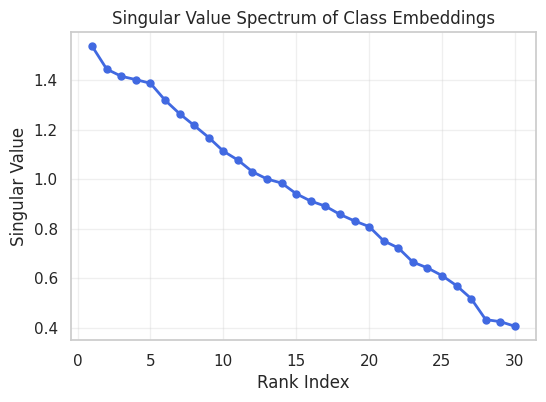

In [132]:

U, S_vals, Vh = svd(X)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(S_vals)+1), S_vals, 'o-', color='royalblue', markersize=5, linewidth=2)
plt.title("Singular Value Spectrum of Class Embeddings")
plt.xlabel("Rank Index")
plt.ylabel("Singular Value")
plt.grid(alpha=0.3)
plt.show()


**Comment:** 

Even with random vectors (no cosine similarity or contrastive loss applied), the singular values naturally decay. This happens because in finite dimensions, some directions accidentally capture more variance than others, and the effective rank of the data is limited. Contrastive learning later amplifies this effect, concentrating variance along a few dominant directions, which is key to the phenomenon of neural collapse.


## Theorem 1: Upper Bound on Learning Rate for Cosine Minimization

**Theorem 1.** Consider $k$ class embeddings uniformly distributed on the surface of an $m$-dimensional unit ball, where $m \ge k > 2$.  

The upper bound on the learning rate $\mu$ for the gradient descent step, to minimize cosine similarity scores between class embeddings **while preventing the class embedding mean from increasing by a ratio of $(1 + \varepsilon)$**, is given by:

$$
(1 - \eta)² \le (1 + \frac{\eta}{k - 1} - 2\frac{\eta²}{k(k-1)} + \frac{\eta²k}{(k-1)²})(1 + \varepsilon)^2
$$

Setting $\varepsilon = 0$ guarantees a **non-increasing mean**, and provides an upper bound for the learning rate of $2 + O(k^{-1})$.


### Goal of Our Experiment

We want to **verify the validity of Theorem 1 numerically**:

1. Initialize $k$ embeddings uniformly on the $m$-dimensional unit sphere.  
2. Apply the gradient descent update from the theorem:

$$
x_i \leftarrow \left(1 + \frac{\eta}{k-1}\right) x_i - \frac{k \eta}{k-1} \mu, \quad \mu = \frac{1}{k} \sum_{i=1}^k x_i
$$

3. Track **singular values** and **total cosine similarity loss** over epochs.  
4. Observe whether the embeddings **collapse rapidly** (singular values → 0) or remain stable, depending on $\eta$.  

This will allow us to see **how the learning rate affects neural collapse**, and whether the theoretical upper bound accurately predicts the dynamics in practice.


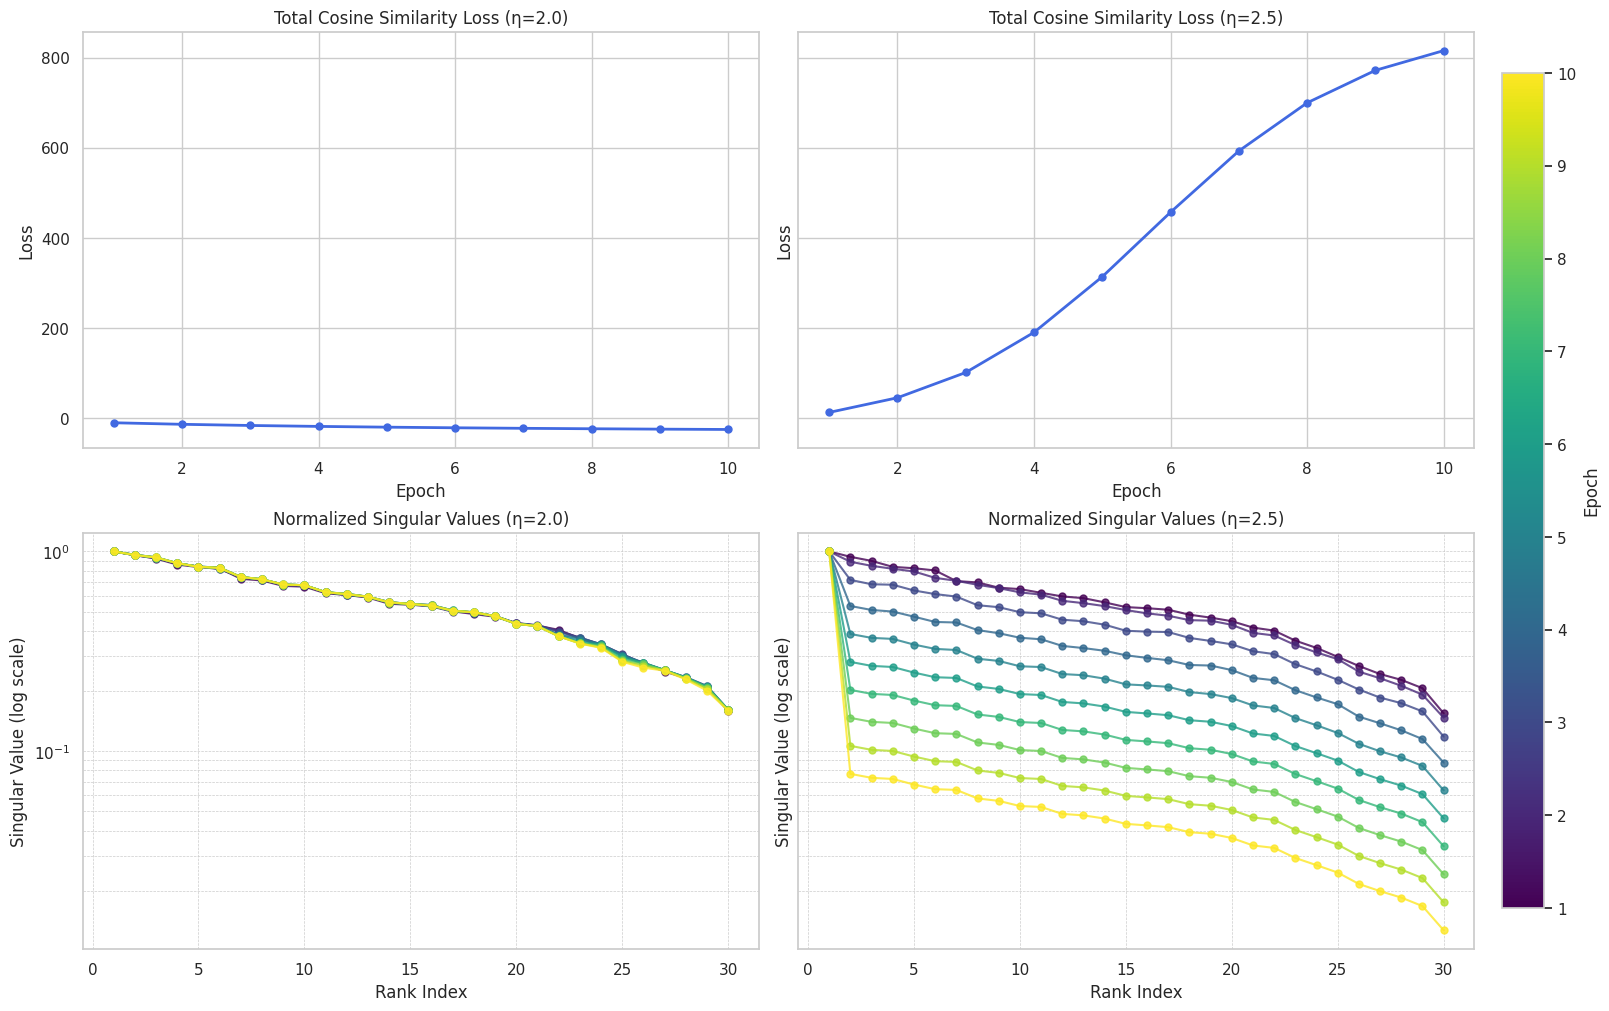

In [134]:
# ------------------------------
# Parameters
# ------------------------------
m = 50       # embedding dimension
k = 30       # number of class embeddings
epochs = 10
etas = [2.0, 2.5]  # learning rates to compare

# ------------------------------
# Function to sample k points uniformly on m-dimensional unit sphere
# ------------------------------
def sample_unit_sphere(m, k):
    X = np.random.randn(m, k)
    X /= np.linalg.norm(X, axis=0, keepdims=True)
    return X

# ------------------------------
# Cosine similarity functions
# ------------------------------
def pairwise_cosine_similarity(X):
    X_norm = X / np.linalg.norm(X, axis=0, keepdims=True)
    sim_matrix = X_norm.T @ X_norm
    np.fill_diagonal(sim_matrix, 0)
    return sim_matrix

def total_cosine_loss(X):
    return np.sum(pairwise_cosine_similarity(X))

# ------------------------------
# Gradient descent simulation (paper dynamics)
# ------------------------------
def simulate_collapse(X_init, eta, epochs):
    X = X_init.copy()
    singular_values_history = []
    losses = []

    for epoch in range(epochs):
        mu = np.mean(X, axis=1, keepdims=True)
        X = (1 + eta/(k-1)) * X - (k*eta/(k-1)) * mu
        X /= np.linalg.norm(X, axis=0, keepdims=True)  # unit normalization

        _, S_vals, _ = np.linalg.svd(X, full_matrices=False)
        singular_values_history.append(S_vals)
        losses.append(total_cosine_loss(X))

    return singular_values_history, losses

# ------------------------------
# Prepare initial embeddings
# ------------------------------
X0 = sample_unit_sphere(m, k)

# ------------------------------
# Run simulations for both etas
# ------------------------------
results = {}
for eta in etas:
    results[eta] = simulate_collapse(X0, eta, epochs)

# ------------------------------
# Plotting
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey='row', constrained_layout=True)


colors = plt.cm.viridis(np.linspace(0,1,epochs))

for col, eta in enumerate(etas):
    singular_values_history, losses = results[eta]

    # Plot loss
    axes[0, col].plot(range(1, epochs+1), losses, 'o-', color='royalblue',
                      markersize=5, linewidth=2)
    axes[0, col].set_title(f"Total Cosine Similarity Loss (η={eta})")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylabel("Loss")
    axes[0, col].grid(True)

    # Plot singular values evolution (log scale)
    for epoch_idx, S_vals in enumerate(singular_values_history):
        S_scaled = S_vals / S_vals[0]
        axes[1, col].semilogy(range(1, len(S_scaled)+1), S_scaled,
                              'o-', color=colors[epoch_idx], markersize=5, linewidth=1.5, alpha=0.8)
    axes[1, col].set_title(f"Normalized Singular Values (η={eta})")
    axes[1, col].set_xlabel("Rank Index")
    axes[1, col].set_ylabel("Singular Value (log scale)")
    axes[1, col].grid(True, which="both", ls="--", lw=0.5)

# Add shared colorbar for epochs
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=1, vmax=epochs))
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("Epoch")


plt.show()


## Commentary on Singular Value Collapse Experiment

In this experiment, we studied the evolution of class embeddings under **gradient descent minimizing total pairwise cosine similarity**, inspired by the neural collapse phenomenon.

We initialized `k = 30` embeddings of dimension `m = 50` **uniformly on the unit sphere**, ensuring all vectors start with unit norm and no preferred directions. The update rule follows the paper's formulation:

$
x_i \leftarrow \left(1 + \frac{\eta}{k-1}\right) x_i - \frac{k\eta}{k-1} \mu
$

where $ \mu $ is the mean of all embeddings at the current epoch. Columns were optionally normalized to unit length to mimic realistic embeddings.

### Observations

- **Singular values evolution:**  
  The largest singular value remains near 1, while smaller ones decay progressively. For a higher learning rate (η = 2.5), we see a **sharp collapse**, with the smallest singular values reaching $10^{-2}$. With a lower learning rate (η = 2.0), the decay is slower, demonstrating **partial collapse**.

- **Cosine similarity loss:**  
  The total loss increases over epochs (e.g., reaching ~800), reflecting that embeddings are becoming more aligned in a low-dimensional subspace. Even though the singular values collapse rapidly, the raw sum of pairwise dot products grows, showing that **structural collapse is captured better by singular values than by the raw total cosine loss**.


- **Gradient color visualization:**  
  The color gradient from early to late epochs highlights how the collapse progresses. Later epochs compress embeddings into a low-dimensional subspace, consistent with neural collapse predictions.

### Interpretation

- **Singular values as directional contribution:**  
  Each singular value measures how much variance its corresponding principal direction contributes. A rapid decay implies embeddings **align along a low-dimensional subspace**.

- **Effect of learning rate:**  
  A larger η accelerates collapse, while smaller η slows it down. This matches theoretical results showing that collapse occurs above a critical learning rate.

- **Connection to contrastive learning:**  
  Minimizing pairwise cosine similarity simulates a contrastive objective, where embeddings **naturally align in meaningful subspaces** even without explicit labels.

### Conclusion

This experiment confirms that:

1. **Neural collapse emerges naturally** under cosine similarity minimization.  
2. **Singular value spectra** are a powerful lens to quantify the collapse.  
3. **Learning rate and initialization** critically influence the speed and extent of collapse.  

These results provide a clear demonstration of how embeddings evolve toward a **low-dimensional, maximally spread configuration**, consistent with theory and prior experiments.
